# LABORATORIO 1.2: Regresión logística, entropía cruzada y capas ocultas.

El objetivo de este segundo laboratorio es tener una primera aproximación computacional al ajuste de una regresión logística. A diferencia del laboratorio anterior (1.1), esta vez usaremos la entropía cruzada como función de pérdida a minimizar. Adicionalmente, tendremos una primera aproximación a el funcionamiento de capas ocultas.

Seguiremos usando la misma problemática del laboratorio 1.1: deseamos crear un clasificador binario que, usando la variable precipitación mensual, pueda predecir si habrá o no un pico de casos de dengue. Usando esta inferencia se espera poder desarrollar medidas preventivas y estar preparados para atender el exceso de casos de esta enfermedad tropical.

1. Lluvias mensuales (unidades = mm de agua).
2. Pico (1) o no (0) casos de dengue en cada mes.

## Fase 1 - Carga de datos y exploración visual

**Objetivo:** cargar los datos del archivo .xlsx y construir unas primeras gráficas de las dos series de tiempo para hacer un primer analisis visual de los datos de entrada..

Para hacer esto, usaremos los paquetes `numpy` para el manejo de estructuras tipo vector, `matplotlib` para hacer gráficos, y `pandas` para manejar estructuras de datos tipo data.frame. Para poder usarlos, los importaremos en nuestro espacio de trabajo:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Para cargar los datos, usamos la función `read_excel` del paquete `pandas`. Esta función tiene un único parámetro obligatorio (la ubicación del archivo de Excel a leer) y varios opcionales (disponibles en https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html). El output de esta función es una variable tipo DataFrame, que en este caso tiene 3 columnas (t, Lluvias, Pico de casos).


**Nota:** Es importante tener el archivo de los datos "datosDengueTangamandapio.xlsx" en la misma carpeta que el código para poderlo cargarlo usando el código suministrado. Si se encuentra en otra carpeta, es necesario añadir toda la ruta de localización.

In [2]:
# Leer el archivo Excel
df = pd.read_excel('datosDengueTangamandapio.xlsx')

Ahora extraeremos los valores de las columnas de las columnas de este DataFrame `df`.

Se puede descomentar las últimas 6 líneas de código para ver cuál es el tipo y tamaño de cada variable.

In [3]:
# Extraer las columnas como vectores (arrays de NumPy)
x_real = df['Lluvias'].values.reshape(-1,1)
y_real = df['Pico de casos'].values.reshape(-1,1)
t = df['t']

# OPCIONAL: Verificamos el tipo y tamaño de cada uno de los vectores
print("Tamaño de t:", t.shape)
print("Tipo de t:", t.dtype, "\n")
print("Tamaño de x_real:", x_real.shape)
print("Tipo de x_real:", x_real.dtype, "\n")
print("Tamaño de y_real:", y_real.shape)
print("Tipo de y_real:", y_real.dtype)

Tamaño de t: (100,)
Tipo de t: datetime64[us] 

Tamaño de x_real: (100, 1)
Tipo de x_real: float64 

Tamaño de y_real: (100, 1)
Tipo de y_real: int64


La primera gráfica que construiremos es una serie de tiempo para ambas variables (precipitación de lluvia y casos de dengue). Esta gráfica tendrá ambas series de tiempo, usando dos ejes Y para poder mostrar el comportamiento de ambas variables. Este tipo de gráficas con doble eje vertical permite ver en simultaneo ambas series de tiempo, evitando el problema de no poder apreciar el comportamiento de una de las variables por diferencias de escalas.

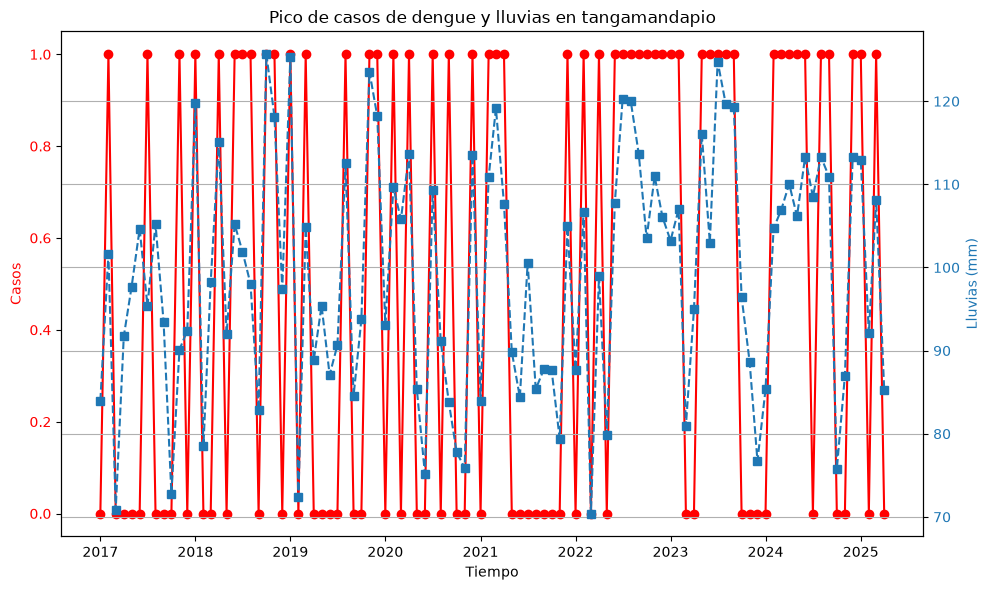

In [4]:
# Creamos la figura y eje principal (izquierdo)
fig1 = plt.figure(figsize=(10, 6))      # El 10 y 6 son las dimensiones (horizontal,vertical) de la gráfica en pulgadas

# Creamos el primer subplot
ax1 = fig1.subplots()
# Definimos el título del eje X
ax1.set_xlabel('Tiempo')
# Graficamos la primera serie de datos (casos)
color_eje1 = 'red'
ax1.plot(t, y_real, color=color_eje1, marker='o', label='Casos')
# Definimos el título del primer eje Y (izquierda)
ax1.set_ylabel('Casos', color=color_eje1)
ax1.tick_params(axis='y', labelcolor=color_eje1)

# Creamos el segundo subplot que compartirá el mismo eje X que el primero
ax2 = ax1.twinx()
# Graficamos y formateamos esta serie de manera similar a la anterior
color_eje2 = 'tab:blue'
ax2.plot(t, x_real, color=color_eje2, marker='s', linestyle='--', label='Lluvias')
ax2.set_ylabel('Lluvias (mm)', color=color_eje2)
ax2.tick_params(axis='y', labelcolor=color_eje2)

# Título y formato de la figura combinada
plt.title('Pico de casos de dengue y lluvias en tangamandapio')
fig1.tight_layout()
plt.grid(True)
plt.show()

La segunda gráfica será un *scatterplot*, donde exploraremos la correlación entre ambas variables. En este caso, usaremos las lluvias mensuales en el eje X al ser una variable continua (mm de columna de agua de lluvia) y también por ser la variable de entrada con la cual queremos predecir si habrá o no picos de casos (la cuál irá en el eje Y).

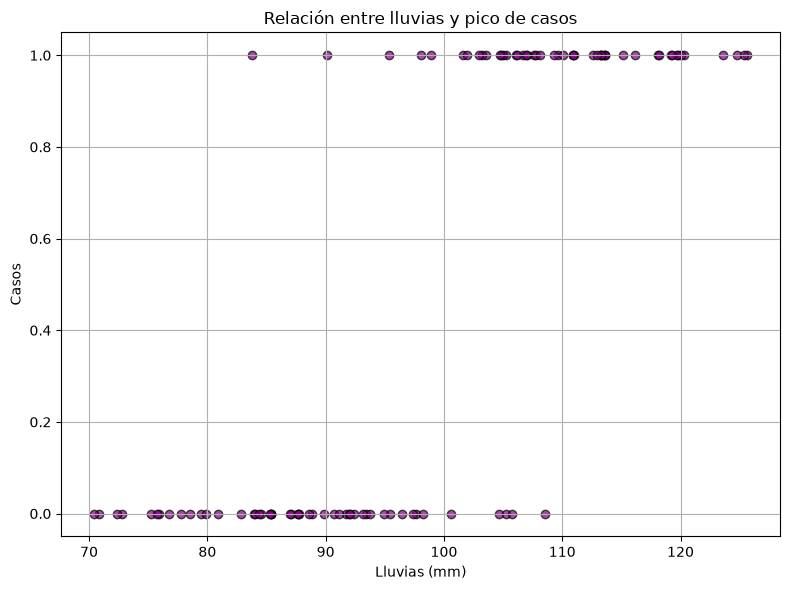

In [5]:
# Creamos el gráfico de dispersión o scatterplot
fig2 = plt.figure(figsize=(8,6))
plt.scatter(x_real, y_real, color='purple', edgecolor='black', alpha=0.7)

# Formateamos la gráfica (títulos de los ejes, título de la gráfica)
plt.xlabel('Lluvias (mm)')
plt.ylabel('Casos')
plt.title('Relación entre lluvias y pico de casos')
plt.grid(True)
plt.tight_layout()
plt.show()

En ambas gráficas se puede observar que existe una relación entre ambas variables.

En el laboratorio 1.1 ajustamos un modelo lineal a estos datos. Sin embargo, es claro al observar el *scatterplot* la característica binaria de la variable "Pico de casos" y que una regresión lineal no es adecuada para estos datos.

Por este motivo, vamos a ajustar una regresión logística.



## Fase 2 - Reescalado y definición de la función de pérdida

Al igual que en laboratorio pasado, lo primero que haremos es reescalar ambas variables para facilitar el ajuste del modelo. El número de casos (`Y`) ya está "escalado" porque sus valores están entre 0 y 1. En cambio, la cantidad de lluvia tiene valores desde 70 mm a 110 mm.

In [6]:
# Reescalamos
X_escalado = (x_real - np.mean(x_real)) / np.std(x_real)
Y_escalado = y_real

**Pregunta:** ¿por qué hacemos una normalización usando el promedio y la desviación estándar (*Z-score normalization*)? ¿Qué problemas podríamos enfrentar si hacemos una normalización usando el rango de la variable ($max(x)-min(x)$) en vez la desviación estándar?

Segundo, vamos a definir una función para nuestro modelo sigmoide. Esta función tendrá como **input** las siguientes variables $ $:

*   Valor de lluvias (normalizadas)
*   Parámetros del modelo:
    *   Peso $ w $
    *   Sesgo $ b $

En esta función primero tenemos una ecuación linea que luego pasa por una función sigmoide. Esta función sería nuestra función de salida o de activación:

In [7]:
# Función de nuestro modelo
# INPUT: vector X (lluvias normalizadas), y los parámetros w y b.
def predict(X, w, b):
    y = X * w + b   # Modelo lineal
    z = 1/(1+np.exp(-y))    #Función sigmoide de salida o activación
    return z

Posteriormente, definiremos la función a minimizar (**función de perdida**). A diferencia de la vez pasada donde usamos la suma de los errores cuadrados (MSE), esta función de pérdida se definirá usando la entropía cruzada:

**Importante:** A nivel matemático, la función sigmoide nunca es 0 ni 1 ya que son los límites en menos infinito e infinito respectivamente. A nivel computacional, una aproximación puede hacer que tome estos valores y por ende tengamos errores en el cálculo de los logarítmos. Por ende, usamos un error *epsilon* de *1e-8*, para evitar que en esos casos se evaluen logarítmos de 0.

In [8]:
# Función de perdida (entropía cruzada)
# INPUT:
#   y_pred: nuestra predicción
#   y_true: las observaciones
def loss_ce(y_pred, y_true):
    epsilon = 1e-8
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - (y_pred + epsilon)))

Definimos también las derivadas parciales de esta función respecto a cada parámetro (peso: $ \frac{\partial f}{\partial w} $ ; sesgo: $ \frac{\partial f}{\partial b} $):

**Pregunta:** ¿cómo obtenemos estas derivadas de manera analítica? **Hint:** tener cuidado con la notación ($z,y$)

In [9]:
# Función que calcula para los valores de un vector X y los valores predichos y observados, cuanto vale la pendiente sobre CE respecto a w y a b.
def grad_ce(X, y_true, y_pred):
    dw = np.mean((y_pred - y_true) * X)
    db = np.mean(y_pred - y_true)
    return dw, db

Y una función que permite buscar el mínimo de la función de perdida a partir de navegar por el gradiente:

In [10]:
# Entrenamiento genérico por grádiente:
# A partir de una condición inicial "realística" sobre w y b, se navega usando un learning rate y se hace un número "epoch" de pasos en esta navegación.
# INPUTS:
#   X, y: valores reales (medidos) de las variables X y Y
#   loss_fn, grad_fn: función de pérdida, y las derivadas de esas funciones de pérdida respecto a los parámetros
#   param_0 = "educated guess" de los valores de los parámetros
#   lr: learning rate
#   epochs: número de épocas
def train(X, y, loss_fn, grad_fn, param_0, lr=0.1, epochs=1000):
    # Hacemos un "educated guess" de los valores de los parámetros
    w = param_0[0]
    b = param_0[1]

    # Inicializamos un vector donde almacenaremos el valor de la función de pérdida en cada época
    losses = []

    for epoch in range(epochs):
        # Para cada época empezamos calculando el valor predicho de la variable de respuesta
        y_pred = predict(X, w, b)
        # Calculamos el valor de la función de pérdida (en este caso, es el MSE)
        loss = loss_fn(y_pred, y)
        # Calculamos el gradiente de la función de pérdida
        dw, db = grad_fn(X, y, y_pred)
        # Avanzamos en el landscape de optimización usando el gradiente. Recordemos que el tamaño del paso está determinado también por el learning rate
        w -= lr * dw
        b -= lr * db
        # Guardamos el valor de pérdidas para luego hacer una gráfica
        losses.append(loss)

        if epoch %10 ==0:
            print(f'Loss at epoch {epoch}: {loss}')

        if epoch > 0 and abs(losses[-1] - losses[-2]) < 1e-10:
            # Paramos el ciclo si el cambio en la función de pérdida es muy pequeño entre épocas
            break
    return w, b, losses

Ya teniendo nuestrás funciones listas, procedemos a hacer el ajuste sobre nuestros datos.

In [11]:
# Ajustar con entropía cruzada
w_ce, b_ce, loss_ce_list = train(X_escalado, Y_escalado, loss_ce, grad_ce, [0.66, -0.2])

print("\n")
print("RESULTADOS AJUSTE ---------------------------------------------------------")
print("Peso ajustado:", w_ce)
print("Bias (sesgo) ajustado:", b_ce)

Loss at epoch 0: 0.4922586648074082
Loss at epoch 10: 0.443398929769611
Loss at epoch 20: 0.40967900265226176
Loss at epoch 30: 0.3853071426033043
Loss at epoch 40: 0.36700917474730843
Loss at epoch 50: 0.3528414934655428
Loss at epoch 60: 0.341593623791256
Loss at epoch 70: 0.33247847010635284
Loss at epoch 80: 0.3249646381834625
Loss at epoch 90: 0.3186815332467045
Loss at epoch 100: 0.3133633572985022
Loss at epoch 110: 0.3088147880106893
Loss at epoch 120: 0.30488922262612933
Loss at epoch 130: 0.30147456613849594
Loss at epoch 140: 0.2984836960643103
Loss at epoch 150: 0.2958479104769889
Loss at epoch 160: 0.29351232878426253
Loss at epoch 170: 0.2914326007260484
Loss at epoch 180: 0.28957251037639226
Loss at epoch 190: 0.28790220420248064
Loss at epoch 200: 0.28639686184515567
Loss at epoch 210: 0.285035685969599
Loss at epoch 220: 0.28380112541407876
Loss at epoch 230: 0.2826782711978532
Loss at epoch 240: 0.2816543821796785
Loss at epoch 250: 0.28071850906123313
Loss at epoch 2

Ya teniendo nuestro modelo ajustado, por último gráficaremos los resultados.

Graficaremos el ajuste de este modelo sobre los datos originales. No debemos olvidar que el ajuste lo hacemos con los datos escalados, por lo que para poder graficar el output del modelo se deben "desescalar" los valores de lluvia:

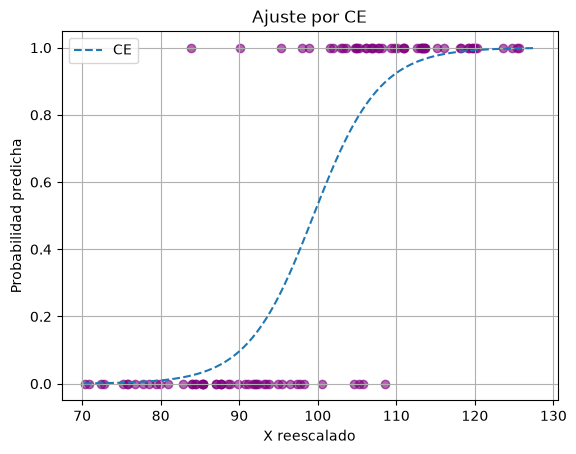

In [12]:
# Crear nueva variable para hacer las predicciones de nuestra regresión.
# La declaramos escalada para luego desescalarla y poderla gráficar junto a los datos crudos.
X_plot_escalado = np.linspace(-2, 2, 100).reshape(-1, 1)
x_plot_desescalado = (X_plot_escalado*np.std(x_real)) + np.mean(x_real)
# Predicciones sobre nuestro modelo usando los parámetros ya ajustados
y_pred_ce = predict(X_plot_escalado, w_ce, b_ce)

# Plot que muestra los datos crudos y nuestro modelo
plt.plot(x_plot_desescalado, y_pred_ce, label="CE", linestyle='--')
plt.scatter(x_real, y_real,color='purple' ,alpha=0.6)
plt.legend()
plt.title("Ajuste por CE")
plt.xlabel("X reescalado")
plt.ylabel("Probabilidad predicha")
plt.grid()
plt.show()

También hacemos un plot que nos permita ver como decae la función de perdida al usar el método del gradiente:

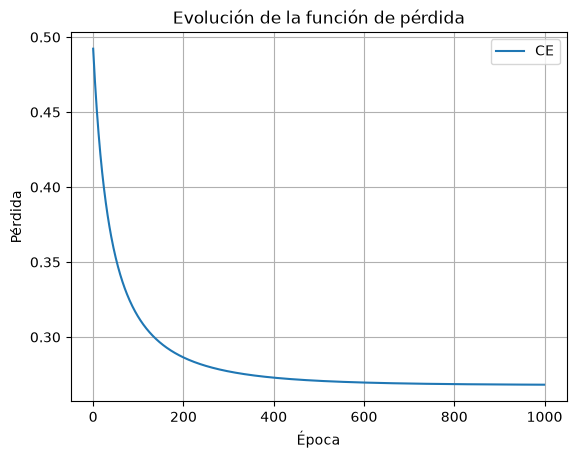

In [13]:
# Curva de perdida
plt.plot(loss_ce_list, label="CE")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.title("Evolución de la función de pérdida")
plt.grid()
plt.show()

## Fase 3 - Métricas de desempeño

Una ves tenemos evaluado el modelo, podemos obtener su desempeño usando varias métricas. Aca definiremos una *matriz de confusión*, que permite ver verdaderos positivos *TP* (Predicciones de 1 correctas), verdaderos negativos *TN* (Predicciones de 0 correctas), falsos positivos *FP* (Predicciones de 1 incorrectas), y falsos negativos *FN* (Predicciones de 0 incorrectas):

| Real / Predicha | Pico (1)                | No pico (0)             |
|-----------------|-------------------------|-------------------------|
| **Pico (1)**    | Verdadero positivo (TP) | Falso negativo (FN)     |
| **No pico (0)** | Falso positivo (FP)     | Verdadero negativo (TN) |

Con base en estos 4 valores podemos obtener varios índices que nos permiten observar que tan bien se ajusta el modelo a los datos.

Definiremos una función que nos sirva para calcular estos parámetros para cualquier modelo que tengamos:

In [14]:
# Función para evaluar el desempeño de nuestro modelo
# INPUT:
#   umbral = límite del valor de salida (sigmoide) a partir del cual consideramos que es un resultado positivo (= sí hay un pico en los casos)
def evaluar_manual(y_true, y_probs, umbral=0.5, epsilon = 1e-8):
    # Convertimos nuestros valores "continuos" de predicción en un binario (0,1) usando nuestro valor de umbral
    y_pred = (y_probs >= umbral).astype(int)

    # Ya con los valores binarios podemos contar qué cantidad de predicciones son verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos
    TP = np.sum((y_pred == 1) & (y_true == 1)) #Verdaderos positivos
    TN = np.sum((y_pred == 0) & (y_true == 0)) #Verdaderos negativos
    FP = np.sum((y_pred == 1) & (y_true == 0)) #Falsos positivos
    FN = np.sum((y_pred == 0) & (y_true == 1)) #Falsos negativos

    # El "accuracy" o exactitud mide cuántas predicciones (positivas o negativas) fueron correctas
    accuracy = (TP + TN) / len(y_true)

    # La precisión mide el total de predicciones positivas correctas (true positivies) respecto al total de predicciones positivas
    precision = TP / (TP + FP + epsilon)

    # El "recall" o exhaustividad
    recall = TP / (TP + FN + epsilon)

    # Y el valor F
    f1 = 2 * precision * recall / (precision + recall + epsilon)

    # Imprimimos los resultados de estos cálculos
    print("Parámetros de desempeño del modelo (calculados manualmente):")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("\n")
    print("Matriz de confusión:")
    print(f"TP: {TP} | FP: {FP}")
    print(f"FN: {FN} | TN: {TN}")

Teniendo definida nuestra función, la aplicamos a los resultados de nuestro modelo y analizamos el desempeño de nuestro clasificador. Para hacer esto, primero debemos calcular las predicciones del modelo a los datos de entrada, y luego usamos la función de cálculo de parámetros de desempeño:

In [15]:
# Obtenemos las probabilidades al aplicar nuestro modelo (es decir, usando los parámetros w y b que estimamos via CE y el método del gradiente)
probs_ce  = predict(X_escalado, w_ce,  b_ce)

# Evaluación de estos resultados:
print("Evaluación modelo con Entropía Cruzada:\n")
evaluar_manual(Y_escalado, probs_ce)

Evaluación modelo con Entropía Cruzada:

Parámetros de desempeño del modelo (calculados manualmente):
Accuracy  : 0.9000
Precision : 0.9000
Recall    : 0.9000
F1-score  : 0.9000


Matriz de confusión:
TP: 45 | FP: 5
FN: 5 | TN: 45


## Fase 4 - Usando 1 capa oculta

Ahora, vamos de volver a definir el mismo modelo pero usando 1 capa oculta, la cual tendra multiples neuronas y no la vamos a entrenar (es decir, cada neurona tendra valores al azar de *peso* y *sesgo*). ¿Qué vamos a entrenar? La neurona de salida, que usa el output de esta capa oculta.

Para esto, usamos el comando *ravel* sobre nuestros datos de entrada para evitar que sean multidimensionales y tengamos problemas en las operaciones matriciales.

In [16]:
X_escalado = np.ravel(X_escalado)
Y_escalado = np.ravel(Y_escalado)

Además, asignamos valores de bias $b$ y peso $w$ a cada neurona de la capa oculta:

In [17]:
# ===== Definición de nuestra capa oculta fija =====

# Fijamos la semilla para nuestro generador de números aleatorios, sólo para tener los mismos resultados cada vez que corramos este código
np.random.seed(0)

# Definimos los valores de b y w de las neuronas de la capa oculta
N_neu = 10
W1 = np.random.randn(1, N_neu)   # Entrada: (Vector datos)= 1 dimensión, neuronas= N_neu dimensiones)
b1 = np.random.randn(N_neu)      # Entrada: (Vector datos)= neuronas= N_neu dimensiones)

# Imprimimos estos valores de w y b
print(f'Pesos: {W1}')
print(f'Sesgos: {b1}')

Pesos: [[ 1.76405235  0.40015721  0.97873798  2.2408932   1.86755799 -0.97727788
   0.95008842 -0.15135721 -0.10321885  0.4105985 ]]
Sesgos: [ 0.14404357  1.45427351  0.76103773  0.12167502  0.44386323  0.33367433
  1.49407907 -0.20515826  0.3130677  -0.85409574]


Ahora tenemos que definir la transformación que hará nuestra capa oculta.

Acá es importante tener en cuenta que la salida serán $N_\text{neu}$ vectores de tamaño del tamaño de nuestros datos. Por ende, esos $N_\text{neu}$ vectores tendran cada uno un peso entrenable en nuestra neurona de salida.

In [18]:
def hidden_layer(X):
    z = np.outer(X, W1.flatten()) + b1  # Tamaño de este array: (n datos, N_lay)

    # Aplicamos la función sigmoide
    return 1 / (1 + np.exp(-z))         # Tamaño de este array: (n datos, N_lay)

Ya con nuestra capa oculta definida, podemos definir nuestro modelo:

In [19]:
# ===== Definición de nuestra capa de salida entrenable =====

def predict_hidd(X, w, b):
    # Calculamos el output de nuestra capa oculta
    h = hidden_layer(X)         # Tamaño de este array: (n datos, N_lay)

    # Esos ouputs serán el input de nuestra capa de salida, que también tendrá la función sigmoide como función de activación
    y = h @ w + b               # Tamaño de h: (n datos, N_lay). Tamaño de w:(N_lay, 1) -> Tamaño de h @ w: (n datos, 1)
    return 1 / (1 + np.exp(-y)) # Tamaño de este array: (n_datos, 1)

Ahora, definimos nuestra función de pérdida (igual a la anterior, usando entropía cruzada):

In [20]:
# Funcion de perdida por entropía cruzada
def loss_ce(y_pred, y_true):
    epsilon = 1e-8
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))  # Tamaño de este array: (n datos)

Y también definimos el gradiente de nuestra función de pérdida.

**Nota:** en este caso, para calcular el gradiente hay que tener en cuenta que el error ($y_\text{pred} - y_\text{real}$) solo como resta es un vector plano (1D; dimensión = número de observaciones) que no permite hacer producto externo con los *N_lay* vectores de salida de la capa oculta. Por esto gracias a *np.newaxis* definimos una nueva dimensión en este array que permita representar este error como una matriz (n,1):

In [21]:
# Funcion del gradiente
def grad_ce(X, y_true, y_pred):
    h = hidden_layer(X)                       # Tamaño: (n datos, N_lay)
    error = (y_pred - y_true)                 # Tamaño: (n datos,)
    error = error[:, np.newaxis]              # Tamaño: (n,1): Importante para poder hacer el producto externo con H que permite obtener el gradiente en w para los N_lay pesos.
    dw = np.mean(h * error, axis=0)           # Tamaño: (N_lay,)
    db = np.mean(y_pred - y_true)             # Tamaño: escalar
    return dw, db

Ahora, definimos el entrenamiento sobre los *N_lay* pesos de nuestra neurona entrenable:

In [22]:
# Entrenamiento genérico por grádiente:
def train(X, y, loss_fn, grad_fn, lr=0.1, epochs=100000):
    # En vez de tener un "educated guess" de los valores de los parámetros como hicimos antes, esta vez los inicializamos aleatoriamente
    w = np.random.randn(N_neu)  # Tamaño: (N_neu,)
    b = np.random.randn()       # Tamaño: escalar
    # Vector donde almacenaremos el valor de la función de pérdida en cada época
    losses = []

    for epoch in range(epochs):
        # Calculamos el valor predicho de la variable de respuesta
        y_pred = predict_hidd(X, w, b)
        # Calculamos el valor de la función de pérdida (en este caso, es el CE)
        loss = loss_fn(y_pred, y)
        # Calculamos el gradiente de la función de pérdida
        dw, db = grad_fn(X, y, y_pred)
        # Avanzamos en el landscape de optimización usando el gradiente
        w -= lr * dw
        b -= lr * db
        # Guardamos el valor de pérdidas de esta época
        losses.append(loss)
        # Early stop
        if epoch % 100 == 0:
            print(f"Epoch {epoch} - Loss: {loss:.6f}")
    return w, b, losses

Después de definir todas las funciones que necesitamos, hacemos el entrenamiento con nuestros datos:

In [23]:
w_final, b_final, losses = train(X_escalado, Y_escalado, loss_ce, grad_ce, lr=0.1, epochs=1000)

print("\n")
print("RESULTADOS AJUSTE ---------------------------------------------------------")
print("Peso ajustado:", w_final)
print("Bias (sesgo) ajustado:", b_final)

Epoch 0 - Loss: 0.785796
Epoch 100 - Loss: 0.418912
Epoch 200 - Loss: 0.345792
Epoch 300 - Loss: 0.314874
Epoch 400 - Loss: 0.298900
Epoch 500 - Loss: 0.289620
Epoch 600 - Loss: 0.283804
Epoch 700 - Loss: 0.279963
Epoch 800 - Loss: 0.277329
Epoch 900 - Loss: 0.275469


RESULTADOS AJUSTE ---------------------------------------------------------
Peso ajustado: [-0.86590126 -0.09025125  1.29797544  1.32696134  3.8703186  -3.89044193
 -0.1249353  -1.11649933  0.50309362  1.65201809]
Bias (sesgo) ajustado: -1.3112878158261072


Por último, evaluamos su capacidad predictiva:

In [24]:
# Obtenemos las probabilidades al aplicar nuestro modelo (es decir, usando los parámetros w y b que estimamos via CE y el método del gradiente)
probs_ce  = predict_hidd(X_escalado, w_final,  b_final)

# Evaluación de estos resultados:
print("Evaluación modelo con Entropía Cruzada:\n")
evaluar_manual(Y_escalado, probs_ce)

Evaluación modelo con Entropía Cruzada:

Parámetros de desempeño del modelo (calculados manualmente):
Accuracy  : 0.9100
Precision : 0.9020
Recall    : 0.9200
F1-score  : 0.9109


Matriz de confusión:
TP: 46 | FP: 5
FN: 4 | TN: 45


Ahora hacemos una gráfica para comparar los resultados de usar una única neurona vs. una capa escondida:

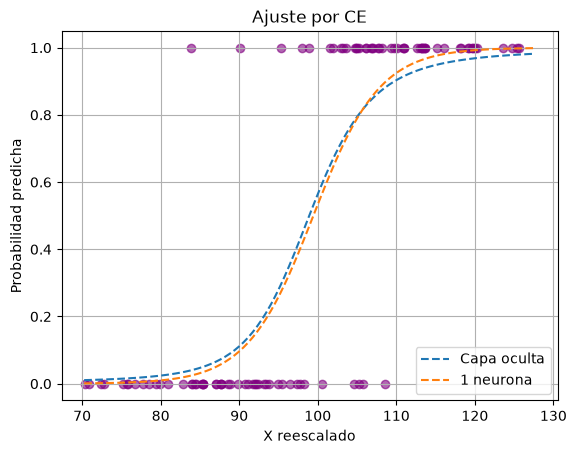

In [25]:
# Crear nueva variable para hacer las predicciones de nuestra regresión. La declaramos escalada para luego desescalarla y poderla gráficar junto a los datos crudos.
X_plot_escalado = np.linspace(-2, 2, 100).reshape(-1, 1)
x_plot_desescalado = (X_plot_escalado*np.std(x_real)) + np.mean(x_real)
# Predicciones sobre nuestro modelo usando los parámetros ya ajustados
y_pred_hid_plot = predict_hidd(X_plot_escalado.flatten(), w_final, b_final)

# Plot que muestra los datos crudos y nuestro modelo
plt.plot(x_plot_desescalado, y_pred_hid_plot, label="Capa oculta", linestyle='--')
plt.plot(x_plot_desescalado,y_pred_ce,label="1 neurona",linestyle='--')
plt.scatter(x_real, y_real,color='purple' ,alpha=0.6)
plt.legend()
plt.title("Ajuste por CE")
plt.xlabel("X reescalado")
plt.ylabel("Probabilidad predicha")
plt.grid()
plt.show()


Y también comparamos la evolución de la función de pérdida entre ambos métodos:

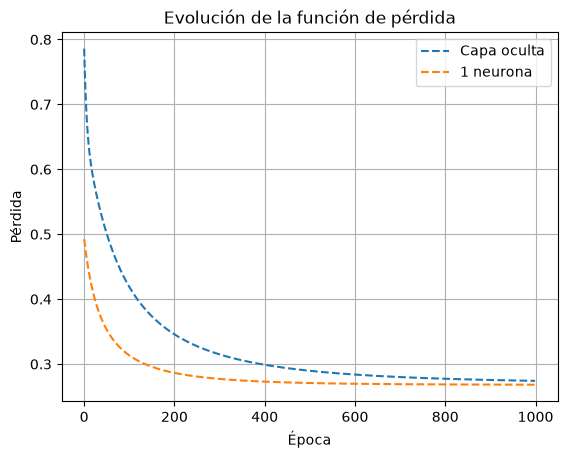

In [26]:
# Curva de perdida
plt.plot(losses, label="Capa oculta", linestyle='--')
plt.plot(loss_ce_list, label="1 neurona", linestyle='--')
plt.xlabel("Época")
plt.ylabel("Pérdida")
#plt.yscale("log")
plt.legend()
plt.title("Evolución de la función de pérdida")
plt.grid()
plt.show()

## QUIZ SEMANA 2:

1. Copie el código en chatGPT o su inteligencia artificial generativa de confianza, y pidale que le explique paso a paso el código. Mencione *3* aprendizajes que haya tenido con la respuesta de su inteligencia artificial generativa de confianza.

2. Explique que diferencia existe entre *np.ravel()* y *np.flatten()*, y mencione su uso dentro del código y el porque es importante.

3. Busque información sobre retropropagación y como esto ayuda a volver ajustables los pesos y sesgos de las capas ocultas.

4. Corra el modelo con distintos números de neuronas en la única capa oculta *(1, 5, 10, 15, 20, 25, 30)*, y haga una gráfica que en el eje x tenga el número de neuronas de la única capa oculta, y en el eje y tenga el valor del *accuracy*. ¿Que puede concluir al respecto? **Nota:** Asegurese que sus redes lleguen a la convergencia.


Esta función recibe el número de neuronas ocultas, genera los pesos fijos de la capa oculta, entrena la capa de salida mediante gradiente descendente y devuelve el accuracy final.

In [27]:
# Función para entrenar una red con N neuronas en la capa oculta
def entrenar_con_ocultas(N_neu, X, y, lr=0.1, epochs=1000, seed=42):
    # Fijamos semilla para reproducibilidad (cada N tendrá sus propios pesos)
    np.random.seed(seed)
    
    # Pesos fijos de la capa oculta
    W1 = np.random.randn(1, N_neu)
    b1 = np.random.randn(N_neu)
    
    # Capa oculta (fija)
    def hidden_layer(X):
        z = np.outer(X, W1.flatten()) + b1
        return 1 / (1 + np.exp(-z))
    
    # Modelo completo (capa oculta fija + capa de salida entrenable)
    def predict_hidd(X, w, b):
        h = hidden_layer(X)
        y = h @ w + b
        return 1 / (1 + np.exp(-y))
    
    # Inicialización de la capa de salida
    w = np.random.randn(N_neu)
    b = np.random.randn()
    
    losses = []
    for epoch in range(epochs):
        y_pred = predict_hidd(X, w, b)
        loss = loss_ce(y_pred, y) 
        
        # Gradiente
        h = hidden_layer(X)
        error = (y_pred - y)[:, np.newaxis]
        dw = np.mean(h * error, axis=0)
        db = np.mean(y_pred - y)
        
        w -= lr * dw
        b -= lr * db
        losses.append(loss)
        
        # Early stopping si la pérdida cambia muy poco
        if epoch > 0 and abs(losses[-1] - losses[-2]) < 1e-10:
            break
    
    # Predicción final y cálculo de accuracy
    y_pred_final = predict_hidd(X, w, b)
    y_pred_bin = (y_pred_final >= 0.5).astype(int)
    accuracy = np.mean(y_pred_bin == y)
    return accuracy, losses

Se prueban las cantidades solicitadas y se almacenan los accuracies.

In [28]:
# Lista de números de neuronas a probar
neuronas = [1, 5, 10, 15, 20, 25, 30]
accuracies = []

print("Entrenando redes con diferente número de neuronas ocultas...")
for n in neuronas:
    acc, _ = entrenar_con_ocultas(n, X_escalado, Y_escalado, lr=0.1, epochs=1000)
    accuracies.append(acc)
    print(f"Neuronas ocultas: {n:2d}  ->  Accuracy: {acc:.4f}")

Entrenando redes con diferente número de neuronas ocultas...
Neuronas ocultas:  1  ->  Accuracy: 0.8900
Neuronas ocultas:  5  ->  Accuracy: 0.9000
Neuronas ocultas: 10  ->  Accuracy: 0.9000
Neuronas ocultas: 15  ->  Accuracy: 0.9000
Neuronas ocultas: 20  ->  Accuracy: 0.9000
Neuronas ocultas: 25  ->  Accuracy: 0.9000
Neuronas ocultas: 30  ->  Accuracy: 0.9100


Se visualiza la relación entre la cantidad de neuronas y el desempeño del modelo.

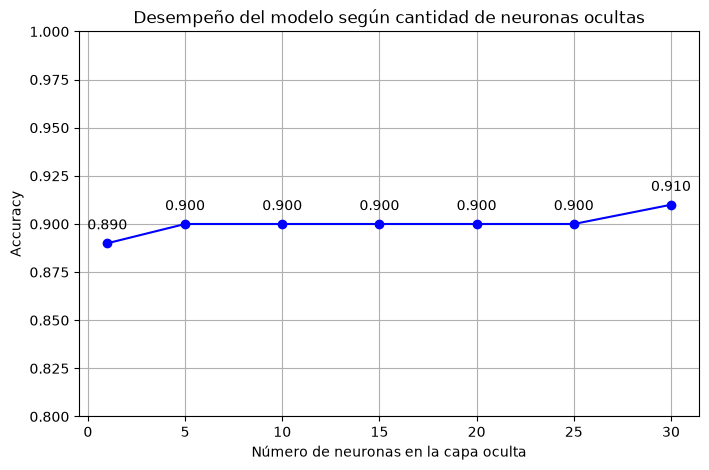

In [29]:
plt.figure(figsize=(8,5))
plt.plot(neuronas, accuracies, marker='o', linestyle='-', color='b')
plt.xlabel("Número de neuronas en la capa oculta")
plt.ylabel("Accuracy")
plt.title("Desempeño del modelo según cantidad de neuronas ocultas")
plt.grid(True)
plt.ylim(0.8, 1.0)   # Ajustar según los resultados
for i, txt in enumerate(accuracies):
    plt.annotate(f"{txt:.3f}", (neuronas[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

**Conclusiones del experimento**

- **Rendimiento y saturación:** El modelo logra un *accuracy* cercano a 0.90 incluso con una sola neurona oculta, lo que indica que el problema de clasificación es relativamente lineal. Al aumentar el número de neuronas ocultas (de 1 a 30), el *accuracy* se estabiliza en valores entre 0.89 y 0.91, sin mostrar mejoras significativas. Esto sugiere que añadir más capacidad al modelo no aporta beneficios claros para este conjunto de datos.

- **Granularidad de la métrica:** Dado que solo se dispone de 100 muestras, el *accuracy* tiene una resolución de 0.01. Por esta razón, varias configuraciones reportan exactamente el mismo valor (0.9000), aunque podrían existir diferencias menores en el número de aciertos (p. ej., 89, 90 o 91 de 100). Esta granularidad debe tenerse en cuenta al interpretar la estabilidad de los resultados.

- **Influencia de la inicialización aleatoria:** La capa oculta es fija y se genera con una semilla aleatoria determinada (\(seed=42\)). Los resultados obtenidos dependen de esa inicialización específica. Cambiar la semilla podría alterar ligeramente el orden o los valores de *accuracy* para cada número de neuronas, por lo que las conclusiones deben contextualizarse bajo esta condición experimental.

- **Convergencia y entrenamiento:** Solo se entrena la capa de salida (regresión logística) mediante descenso por gradiente, mientras que la capa oculta permanece fija. Dado que la función de pérdida (entropía cruzada) para la capa de salida es convexa, se garantiza que el entrenamiento converge al mínimo global para cada configuración, lo que valida la comparación entre arquitecturas.

- **Sobreajuste y tamaño de datos:** Aunque añadir más neuronas aumenta la capacidad del modelo, no se observa sobreajuste (el *accuracy* no empeora). Sin embargo, con solo 100 muestras, el riesgo de sobreajuste existe; la estabilidad del *accuracy* sugiere que la capa oculta fija actúa como un mecanismo de regularización implícita que limita la complejidad efectiva del modelo.

5. Para los modelos del punto anterior con 1, 15 y 30 neuronas de la única capa oculta, haga los esquemas de las redes (el gráfico con sus neuronas, variables de entrada, y la neurona de salida), sume el total de pesos y bias tanto para las capas ocultas como para la ajustable para reportar el número total de parámetros, y muestre las transformaciones algebraicas en terminos de dimensiones de matrices a cada nivel de la red. (Dimensión datos entrada, dimensión salida de la capa oculta, dimensión salida unica neurona ajustable).